## 05. Pytorch Custom Dataset NoteBook.




In [269]:
import torch
from torch import nn

# Note Pytorch 1.10.0+ is required for this course
torch.__version__

'2.10.0+cpu'

In [270]:
# setup device agnostic
device ="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [271]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


### 1. Get data

our dataset is a subset of the food01 dataset.


In [272]:
import requests
import zipfile
from pathlib import Path

# setup paths
data_path = Path("data")
image_path = data_path / "pizza_steak_sushi"
zip_path = data_path / "pizza_steak_sushi.zip"

# create folders if they don't exist
data_path.mkdir(parents=True, exist_ok=True)

if image_path.is_dir():
    print(f"{image_path} directory already exists... skipping download")
else:
    print(f"{image_path} does not exist, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # correct raw GitHub URL
    url = "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/data/pizza_steak_sushi.zip"

    print("Downloading pizza, steak, sushi data...")
    response = requests.get(url)

    # check if download worked
    if response.status_code == 200:
        with open(zip_path, "wb") as f:
            f.write(response.content)
    else:
        raise Exception(f"Download failed! Status code: {response.status_code}")

    # check if it's a valid zip file
    if zipfile.is_zipfile(zip_path):
        print("Unzipping pizza, steak and sushi data...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(image_path)
    else:
        raise Exception("Downloaded file is not a valid zip file!")

data/pizza_steak_sushi directory already exists... skipping download


In [273]:
data_path / "pizza_steak_sushi.zip"

PosixPath('data/pizza_steak_sushi.zip')

### 2. Becoming one with the data ( data preparation and data exploration)

In [274]:
import os
def walk_through_dir(dir_path):
  """ walks through dir_path its contents"""

  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [275]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.


In [276]:
# setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"



train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing and image

1. Get write some code to:
2. pick a random image path using python's random.choice()
3. Get the image class name using pathlib.path.parent.stem
4. since we're working with images, let's open the image with python's PIL
5. we'll then show the image and print metadata

In [277]:
image_path

PosixPath('data/pizza_steak_sushi')

data/pizza_steak_sushi/train/pizza/764429.jpg
pizza
Random image path: data/pizza_steak_sushi/train/pizza/764429.jpg
Image class: pizza
Image height: 341
Image width: 512


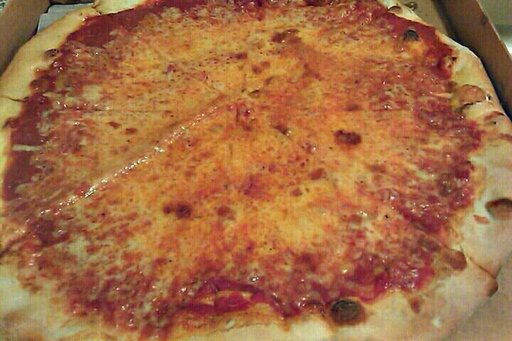

In [278]:
import random
from PIL import Image

# set seed

# 1. Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. pick a random image path
random_image_path = random.choice(image_path_list)
print(random_image_path)

# 3. Get image class from path name (the image class is the name of the dictionary where the )
image_class = random_image_path.parent.stem
print(image_class)

# open image
img = Image.open(random_image_path)


# 5. print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(340.5), np.float64(-0.5))

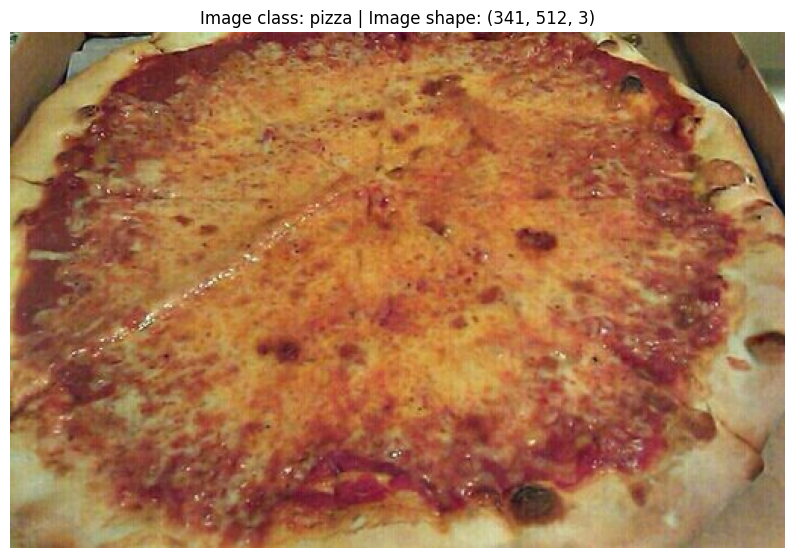

In [279]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape}")
plt.axis("off")

array([[[ 82,  89,  73],
        [ 57,  66,  47],
        [ 93, 105,  83],
        ...,
        [113, 107,  75],
        [116, 105,  77],
        [123, 112,  84]],

       [[ 99, 108,  91],
        [ 99, 111,  91],
        [123, 137, 114],
        ...,
        [120, 111,  80],
        [121, 110,  82],
        [127, 116,  88]],

       [[188, 203, 184],
        [168, 183, 162],
        [132, 150, 126],
        ...,
        [122, 113,  82],
        [122, 111,  81],
        [125, 114,  84]],

       ...,

       [[128, 131,  78],
        [131, 131,  79],
        [128, 122,  70],
        ...,
        [177, 144, 103],
        [180, 145, 107],
        [183, 147, 111]],

       [[130, 133,  80],
        [134, 134,  82],
        [130, 124,  72],
        ...,
        [176, 142, 104],
        [180, 144, 108],
        [183, 147, 111]],

       [[132, 135,  82],
        [138, 138,  86],
        [135, 129,  77],
        ...,
        [175, 141, 103],
        [180, 144, 108],
        [183, 147, 113]]], dtype=uint8)
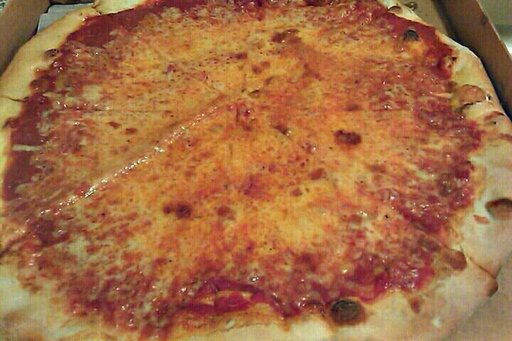

In [280]:
img_as_array

### 3. Transforming data

1. turn your data target data into tensor
2. turn it into a torch.utils.data.dataset

In [281]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


### 3.1 Transforming data with torchvision.transforms

In [282]:
# wtrite a transform for image
data_transform = transforms.Compose([
    # Resize our image to 64x64
   transforms.Resize(size=(64, 64)),
    #Filp the image randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    # Turn the image into a torch.Tensor
    transforms.ToTensor()
])

In [283]:
data_transform(img)

tensor([[[0.4706, 0.5216, 0.4627,  ..., 0.4549, 0.4431, 0.4471],
         [0.5059, 0.5098, 0.4667,  ..., 0.4392, 0.4275, 0.4392],
         [0.5373, 0.5020, 0.4627,  ..., 0.4314, 0.4118, 0.4275],
         ...,
         [0.5451, 0.5922, 0.6392,  ..., 0.6039, 0.6039, 0.6235],
         [0.5333, 0.5765, 0.6078,  ..., 0.6157, 0.6235, 0.6471],
         [0.5294, 0.5451, 0.5569,  ..., 0.6392, 0.6510, 0.6784]],

        [[0.4980, 0.4275, 0.3608,  ..., 0.4353, 0.4314, 0.4275],
         [0.4745, 0.3961, 0.3608,  ..., 0.4275, 0.4235, 0.4235],
         [0.4431, 0.3882, 0.3608,  ..., 0.4157, 0.4196, 0.4118],
         ...,
         [0.4549, 0.4902, 0.5412,  ..., 0.5098, 0.5137, 0.5255],
         [0.4510, 0.4863, 0.5020,  ..., 0.5176, 0.5333, 0.5451],
         [0.4667, 0.4588, 0.4392,  ..., 0.5373, 0.5490, 0.5647]],

        [[0.3765, 0.2745, 0.2196,  ..., 0.3020, 0.2980, 0.2941],
         [0.3451, 0.2275, 0.2118,  ..., 0.2863, 0.2902, 0.2824],
         [0.2980, 0.2471, 0.2275,  ..., 0.2706, 0.2745, 0.

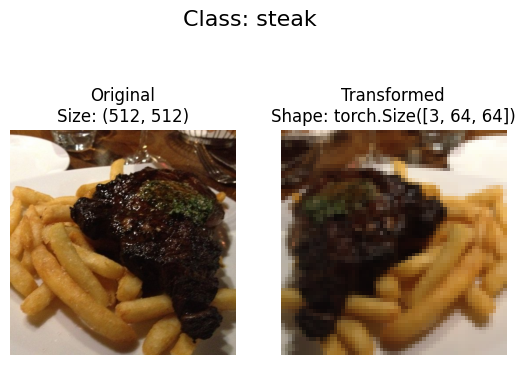

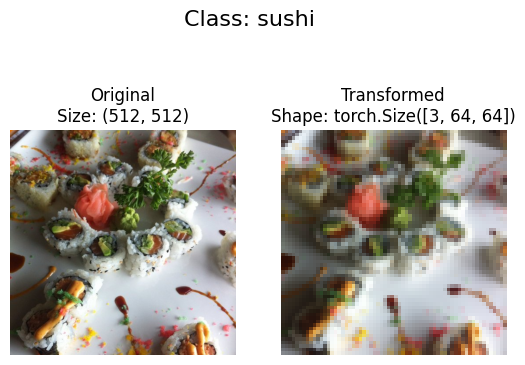

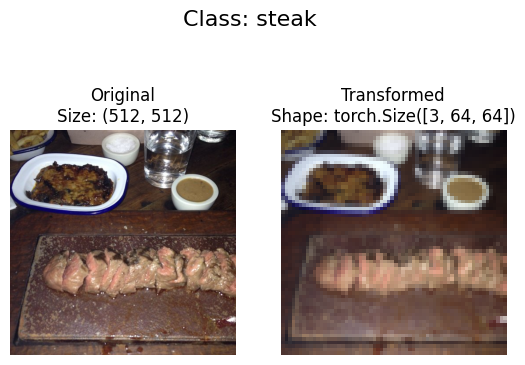

In [284]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """
    Selects random images from a path of images and loads/transforms
    them, then plots the original vs the transformed version.
    """
    if seed:
        random.seed(seed)

    random_image_paths = random.sample(image_paths, k=n)

    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)

            # Original image
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)

            # Transform and plot
            transformed_image = transform(f)
            ax[1].imshow(transformed_image.permute(1, 2, 0))  # for PyTorch tensors
            ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            ax[1].axis(False)

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)
            plt.show()


plot_transformed_images(
    image_paths=image_path_list,
    transform=data_transform,
    n=3,
    seed=None
)

In [285]:
image_path_list

[PosixPath('data/pizza_steak_sushi/test/sushi/1600999.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2385731.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3196729.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1245193.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/499605.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1434806.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/988559.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1172255.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3837522.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2276986.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2540511.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/858157.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1742201.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/175783.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2394442.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/207578.jpg'),
 PosixPath('data/pizza_steak_

### Option 1: Loading image data using 'ImageFolder'



In [286]:
# use image folder to create dataset()
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [287]:
train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [288]:
# Get class names as list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [289]:
# Get class names as a dictionary
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [290]:
# check the lengh of our dataset
len(train_data), len(test_data)

(225, 75)

In [291]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [292]:
# Index on the train_data datasets to get a single image and label
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n {img}")
print(f"Image shape:\n {img.shape}")
print(f"Image datatype:\n {img.dtype}")
print(f"Image label:\n {label}")
print(f"Label dtype:\n {type(label)}")

Image tensor:
 tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.0

Original shape: torch.Size([3, 64, 64])
Image permute: torch.Size([64, 64, 3])


Text(0.5, 1.0, 'pizza')

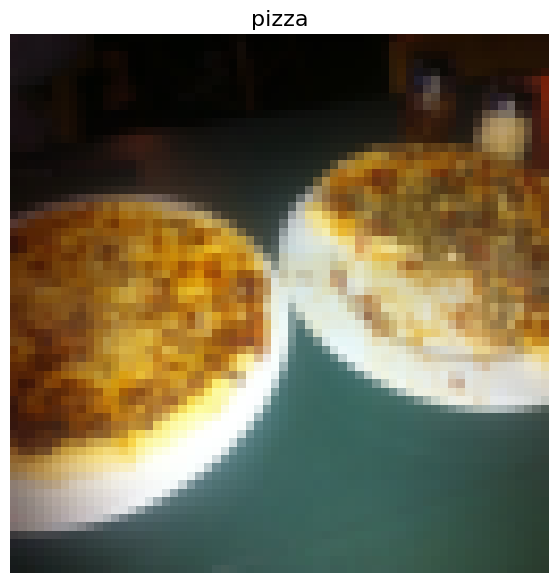

In [293]:
# Rearrange the order dimension
img_permute = img.permute(1, 2, 0)

# print out different shape
print(f"Original shape: {img.shape}")
print(f"Image permute: {img_permute.shape}")


# plot the shape
plt.figure(figsize=(10, 7))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_names[label], fontsize=16)

### 4.1 Turn loaded image into 'Dataloader's

In [294]:
# turn train and test datasets into dataloader's
from torch.utils.data import DataLoader
BATCH_SIZE=1
train_dataloader = DataLoader(dataset=train_data,
                              batch_size= 1,
                              num_workers=1,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=1,
                             num_workers=1,
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7cd837be89b0>,
 <torch.utils.data.dataloader.DataLoader at 0x7cd8226c80b0>)

In [295]:
len(train_dataloader), len(test_dataloader)

(225, 75)

In [296]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1, you can change the batch size if you like
print(f"Image shape: {img.shape}")
print(f"Label sahpe: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64])
Label sahpe: torch.Size([1])


### 5. Option 2: Loading image data with a custom dataset

In [297]:
import os
import pathlib
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [298]:
# instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names


In [299]:
# setup path for target directory
target_directory = train_dir
print(f"Target dir: {target_directory}")

# Get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target dir: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [300]:
 list(os.scandir(target_directory))

[<DirEntry 'sushi'>, <DirEntry 'pizza'>, <DirEntry 'steak'>]

In [301]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
  """ Find the classes folder names in a target directory."""

  # 1. Get the class names by scanning the target directory
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  # 2. Raise an error if class names could not be found
  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}... please check file structure.")

  # 2. Create a directory of index labels (computers prefer numbers rather than strings as labels)
  class_to_idx = {class_name: i for i, class_name in enumerate(classes)}
  return classes, class_to_idx


In [302]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a custom 'dataset' to replicate 'ImageFolder'

1. subclass 'torch.utils.data.dataset'
2. Init our subclass with a target directory( the directory we'd like to get data)
3. Create several atributes:
  * pathes- paths for our images
  * transform- the transform we'd like to use
  * classes- a list of the target classes
  * class_to_idx - a dict of the target classes mapped to integer labels

4. Create a function to load_images() this function will open an image
5. Overwrite the __len()__method to return the length of our dataset
6. Overwrite the __getitem()__ method to return a given sample when passed an index

In [303]:
# write a custom dataset class
import pathlib
import torch
from PIL import Image
from torch.utils.data import Dataset
from typing import Tuple

# 1. Subclass Dataset
class ImageFolderCustom(Dataset):

    # 2. Initialize our custom dataset
    def __init__(self, target_dir: str, transform=None):

        # 3. Create class attributes
        # Get all image paths
        self.paths = list(pathlib.Path(target_dir).glob("*/*.jpg"))

        # Setup transforms
        self.transform = transform

        # Create classes and class_to_idx
        self.classes, self.class_to_idx = find_classes(target_dir)

    # 4. Create a function to load image
    def load_image(self, index: int) -> Image.Image:
        """Opens an image via a path and returns it."""
        image_path = self.paths[index]
        return Image.open(image_path)

    # 5. Overwrite __len__()
    def __len__(self) -> int:
        """Returns total number of samples."""
        return len(self.paths)

    # 6. Overwrite __getitem__()
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        """Returns one sample of data (image, label)."""

        img = self.load_image(index)

        # Get class name from path
        class_name = self.paths[index].parent.name

        # Convert class name to index
        class_idx = self.class_to_idx[class_name]

        # Apply transform if exists
        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx

In [304]:
# create transforms
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

In [305]:
# test out ImageFolderCustom
train_data_custom = ImageFolderCustom(
    target_dir=train_dir,
    transform=test_transforms
)

In [306]:
test_data_custom = ImageFolderCustom(
    target_dir=test_dir,
    transform=test_transforms
)

In [307]:
len(train_data), len(train_data_custom)

(225, 225)

In [308]:
len(test_data), len(test_data_custom)

(75, 75)

In [309]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [310]:
# check for equality between original ImageFolder dataset and ImageFolderCustomDataset
print(train_data_custom.classes==train_data.classes)
print(test_data_custom.classes==test_data.classes)

True
True


### 5.3 Create a function to display random image

1. Take in a 'dataset' and a number of other parameters such as class names ans how may image to visualize.
2. to prevent the display getting out of hand,
3. set the random seed for reproducibility
4. get a list of random sample indexs from the target datasets.
5. setup a matplotlib plot
6. loop through the random sample images and plot them with matplotlib.
7. Make sure the dimensions of our images line up with matplotlib(HWC)

In [311]:
import random
import matplotlib.pyplot as plt
import torch
from typing import List

# 1. create a function to take in a dataset
def display_random_images(
    dataset: torch.utils.data.Dataset,
    classes: List[str] = None,
    n: int = 10,
    display_shape: bool = True,
    seed: int = None
):

    # 2. Adjust display if n is too high
    if n > 10:
        n = 10
        display_shape = False
        print("For display purposes, n shouldn't be larger than 10. Setting n=10 and removing shape display.")

    # 3. set the seed
    if seed is not None:
        random.seed(seed)

    # 4. get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # 5. setup plot
    plt.figure(figsize=(16, 8))

    # 6. Loop through random indexes and plot them
    for i, targ_sample in enumerate(random_samples_idx):
        target_image, targ_label = dataset[targ_sample]

        # 7. Adjust tensor dimensions for plotting
        targ_image_adjust = target_image.permute(1, 2, 0)

        # Plot
        plt.subplot(1, n, i + 1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")

        if classes:
            title = f"Class: {classes[targ_label]}"
            if display_shape:
                title += f"\nshape: {targ_image_adjust.shape}"
            plt.title(title)

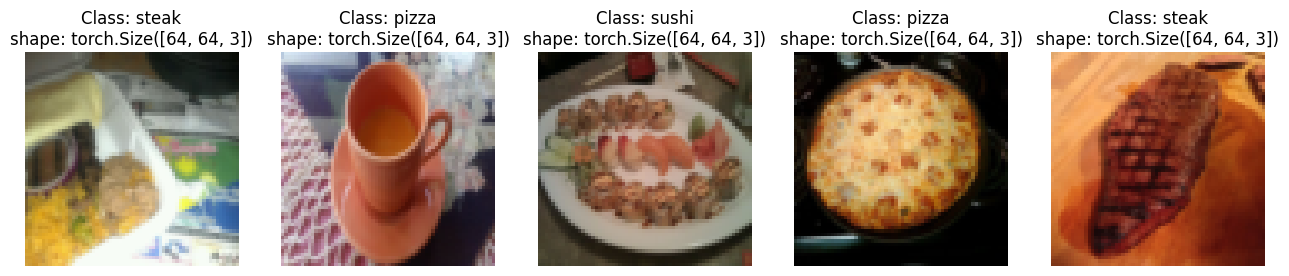

In [312]:
# display random images from the ImageFolderCustom dataset
display_random_images(
    train_data,
    n=5,
    classes=class_names,
    seed=None
)

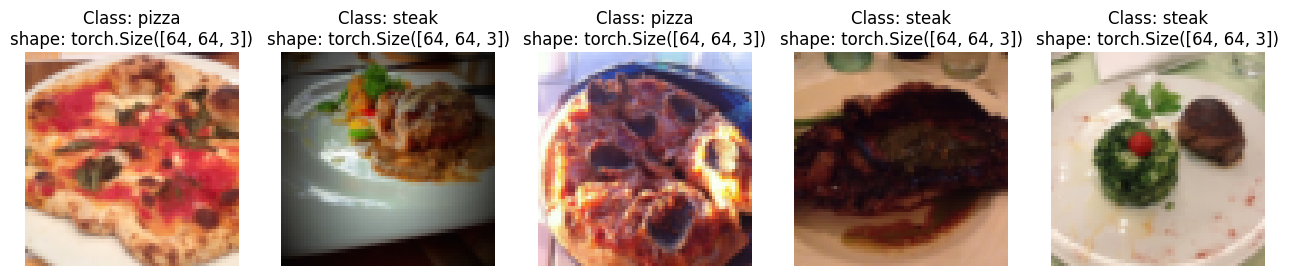

In [313]:
# display random images from the ImageFolderCustom dataset
display_random_images(train_data_custom,
                      n=5,
                      classes=class_names,
                      seed=None)

### 5.4 Turn custom loaded images into DataLOaders's

In [314]:
from torch.utils.data import DataLoader
BATCH_SIZE = 1
NUM_WORKERS= os.cpu_count()
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size= BATCH_SIZE,
                                     num_workers=NUM_WORKERS,
                                     shuffle=False)
test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size=BATCH_SIZE,
                                    num_workers=NUM_WORKERS,
                                    shuffle=False)
train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7cd822475af0>,
 <torch.utils.data.dataloader.DataLoader at 0x7cd820b7c4a0>)

In [315]:
# Get image and label from custom dataloader
img_custom, label_custom = next(iter(train_dataloader_custom))

# print out the image shapes
img_custom.shape, label_custom.shape

(torch.Size([1, 3, 64, 64]), torch.Size([1]))

### 6. Other forms of transforms (data augmentation)

Data augmentation is the process of artificially adding  diversity to your training data.
In the case of image data, this may mean applying various images transformation to the training images.

This practies hopefully results in a model that's more generalizable to unseen data.
Let's take a look at one particular type of data augmentation used to train PyTorch vision model's to state of the art level's...

In [316]:
# Let's look at
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor()
])

In [317]:
image_path

PosixPath('data/pizza_steak_sushi')

In [318]:
# Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/test/sushi/1600999.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2385731.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3196729.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1245193.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/499605.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1434806.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/988559.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1172255.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3837522.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2276986.jpg')]

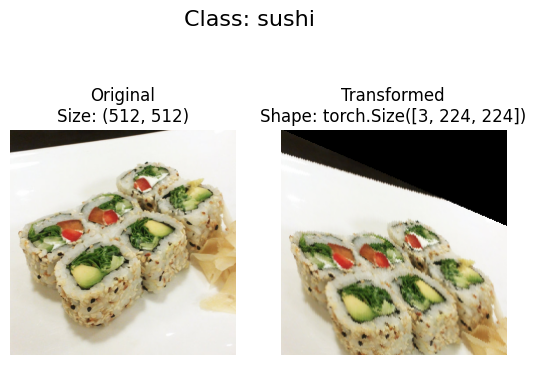

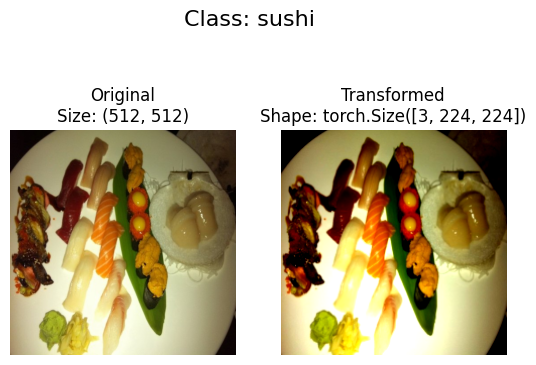

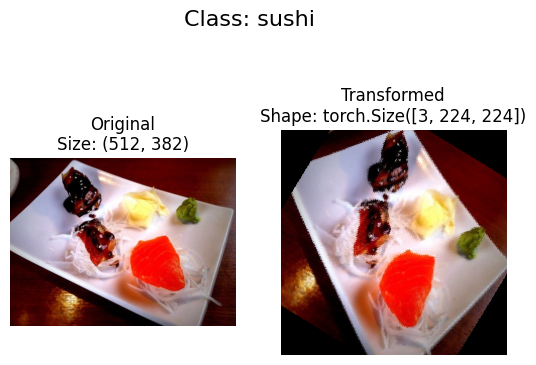

In [319]:
# plot random transforms images
plot_transformed_images(
    image_paths = image_path_list,
    transform = train_transform,
    n=3,
    seed = None
)

### 7. Model 0: TinyVGG without data augmentation

#### 7.1 creating transforms and loading data for model 0

In [320]:
# creating simple transforms
simple_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

In [321]:
# 1. Load and transform data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,
                                       transform=simple_transform)

test_data_simple = datasets.ImageFolder(root=test_dir,
                                       transform=simple_transform)

# 2. Turn the datasets into Dataloaders
import os
from torch.utils.data import DataLoader

# setup batch size and number of workers
BATCH_SIZE=32
NUM_WORKERS=os.cpu_count()

# Create DataLoader's
train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     shuffle = True,
                                     num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                     batch_size=BATCH_SIZE,
                                     shuffle = False,
                                     num_workers=NUM_WORKERS)


#### 7.2 Create TinyVGG model class

In [322]:
class TinyVGG(nn.Module):
  """
  Model architecture coping TinyVGG from CNN Explainer
  """
  def __init__(self, input_shapes: int,
               hidden_units: int,
               output_shape: int) -> None:

    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shapes,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                    stride=2 ) # default stride value is same as kernel_size
     )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                    stride=2 )
    )
    self.classifier =nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=hidden_units*16*16,
              out_features=output_shape)
    )
  def forward(self, x):
    x = self.conv_block_1(x)
    print(x.shape)
    x = self.conv_block_2(x)
    print(x.shape)
    x = self.classifier(x)
    return x
    #return self.classifier(self.conv_block_2(self.conv_block_1(x)))





In [323]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shapes=3, # number of color channels inour image data
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

#### 7.3 Try a forward pass on a single image(to test the model)

In [324]:
# get a single image batch
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [325]:
# try a forward pass
model_0(image_batch.to(device))

torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])


tensor([[0.0578, 0.0634, 0.0351],
        [0.0657, 0.0650, 0.0398],
        [0.0702, 0.0678, 0.0412],
        [0.0687, 0.0646, 0.0417],
        [0.0625, 0.0613, 0.0355],
        [0.0587, 0.0595, 0.0358],
        [0.0634, 0.0637, 0.0376],
        [0.0653, 0.0615, 0.0376],
        [0.0678, 0.0621, 0.0349],
        [0.0620, 0.0599, 0.0371],
        [0.0607, 0.0628, 0.0387],
        [0.0638, 0.0589, 0.0352],
        [0.0658, 0.0611, 0.0369],
        [0.0703, 0.0689, 0.0330],
        [0.0557, 0.0571, 0.0356],
        [0.0632, 0.0642, 0.0388],
        [0.0639, 0.0616, 0.0375],
        [0.0605, 0.0600, 0.0374],
        [0.0623, 0.0627, 0.0368],
        [0.0740, 0.0676, 0.0400],
        [0.0621, 0.0613, 0.0361],
        [0.0632, 0.0599, 0.0366],
        [0.0662, 0.0627, 0.0334],
        [0.0637, 0.0622, 0.0394],
        [0.0670, 0.0666, 0.0363],
        [0.0650, 0.0601, 0.0405],
        [0.0639, 0.0597, 0.0395],
        [0.0733, 0.0687, 0.0412],
        [0.0697, 0.0631, 0.0402],
        [0.062

#### 7.4 Use torchinfo to get an idea of the shapes going through our model

In [326]:
# Install torchinfo, import if it's available
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary
summary(model_0, input_size=[1, 3, 64, 64])

torch.Size([1, 10, 32, 32])
torch.Size([1, 10, 16, 16])


Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

#### 7.5 Create train and test loops functions

* train_step()
* test_step()

In [327]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device=device):

    model.train()
    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(dataloader):  # ✅ FIXED name
        X, y = X.to(device), y.to(device)

        # Forward pass
        y_pred = model(X)

        # Loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accuracy (simplified)
        y_pred_class = y_pred.argmax(dim=1)  # ✅ FIXED (no softmax)
        train_acc += (y_pred_class == y).sum().item() / len(y)

    train_loss /= len(dataloader)  # ✅ FIXED
    train_acc /= len(dataloader)

    return train_loss, train_acc

In [328]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device=device):

    model.eval()
    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(y)

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)

    return test_loss, test_acc

#### 7.6 Create a train() function to combine train_step() and test_step()

In [329]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int = 5,
          device=device):

    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(
            model=model,
            dataloader=train_dataloader,  # ✅ FIXED
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device
        )

        test_loss, test_acc = test_step(
            model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
            device=device
        )

        print(f"Epoch: {epoch} | "
              f"Train loss: {train_loss:.4f} | "
              f"Train acc: {train_acc:.4f} | "
              f"Test loss: {test_loss:.4f} | "
              f"Test acc: {test_acc:.4f}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

#### 7.7 Train and evaluate model 0

In [330]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shapes=3,  # number of color channels of our target images
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model
model_0_results = train(
    model=model_0,
    train_dataloader=train_dataloader_simple,  # ✅ FIXED
    test_dataloader=test_dataloader_simple,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS,
    device=device
)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([1, 10, 32, 32])
torch.Size([1, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([11, 10, 32, 32])
torch.Size([11, 10, 16, 16])
Epoch: 0 | Train loss: 1.1078 | Train acc: 0.2578 | Test loss: 1.1362 | Test acc: 0.2604
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32

In [331]:
model_0_results

{'train_loss': [1.1078356951475143,
  1.0846453607082367,
  1.1152610331773758,
  1.0990152657032013,
  1.0989657938480377],
 'train_acc': [0.2578125, 0.42578125, 0.29296875, 0.2890625, 0.29296875],
 'test_loss': [1.1362075010935466,
  1.1621707677841187,
  1.169488827387492,
  1.1343015034993489,
  1.14342466990153],
 'test_acc': [0.2604166666666667,
  0.19791666666666666,
  0.19791666666666666,
  0.19791666666666666,
  0.19791666666666666]}

### Plot the loss curves of model 0

* A loss curve is a way of tracking your model's progress over time.

In [332]:
# get the model_0_results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [333]:
import matplotlib.pyplot as plt
from typing import Dict, List

def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training and testing loss + accuracy curves."""

    # Get values from results dictionary
    train_loss = results["train_loss"]
    test_loss = results["test_loss"]
    train_acc = results["train_acc"]
    test_acc = results["test_acc"]

    # Epochs
    epochs = range(len(train_loss))

    # Setup figure
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="train_accuracy")
    plt.plot(epochs, test_acc, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

    plt.show()

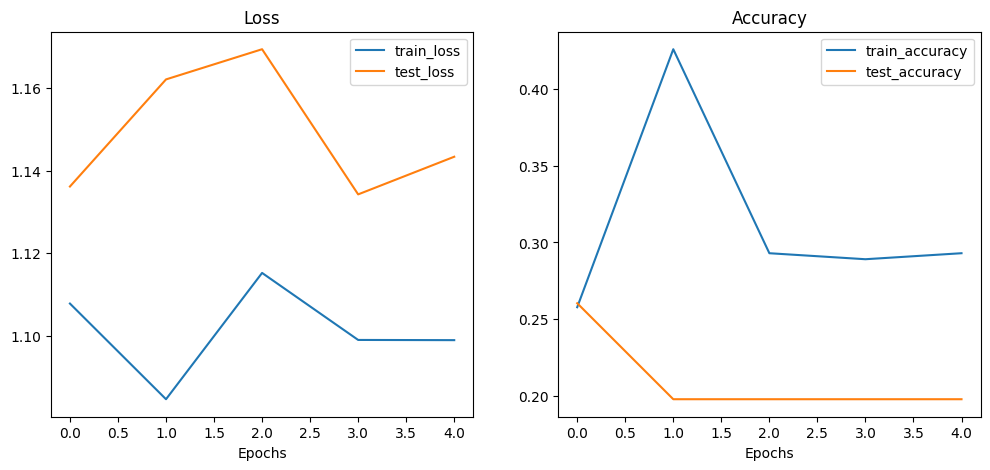

In [334]:
plot_loss_curves(model_0_results)

### 8. what should an ideal loss curve look like?

* A loss is one of the most helpful ways to trublshot the model.

### 9. Model 1: YinyVGG with Data Augmentation

#### 9.1 Create transform with data augmentation

In [335]:
# create training transform with TiriviailAugment
from torchvision import transforms
train_transform_trivial = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])


test_transform_trivial = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

#### 9.2 Create train and test dataset's and dataloader's with data augmentation

In [336]:
# Turn image folders into Datasets
from torchvision import datasets
train_data_augmented = datasets.ImageFolder(root=train_dir,
                                            transform=train_transform_trivial)

test_data_augmented = datasets.ImageFolder(root=test_dir,
                                            transform=test_transform_trivial)


In [337]:
# Turn our Datasets into Dataloader
import os
from torch.utils.data import DataLoader
BATCH_SIZE =32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(dataset=train_data_augmented,
                                        batch_size=BATCH_SIZE,
                                        shuffle=True,
                                        num_workers=NUM_WORKERS)

test_dataloader_augmented = DataLoader(dataset=test_data_augmented,
                                        batch_size=BATCH_SIZE,
                                        shuffle=True,
                                        num_workers=NUM_WORKERS)

### 9.3 Construct and train model 1:

In [338]:
# create model_1 and send it to the target device
torch.manual_seed(42)
model_1 = TinyVGG(input_shapes=3,
                  hidden_units=10,
                  output_shape=len(train_data_augmented.classes)).to(device)

model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

Wonderful ! Now we've a model and dataloaders, let's create a loss function and an optimizer and call our train and evaluate our model.

In [339]:
from numpy.matrixlib import test
# set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# set the number of epochs
epochs = 5

# setup loss function
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.01)

# start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_1
model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        device=device)
# End the timer and print out how long it tooks
end_time=timer()
print(f"Total training time for model_1: {end_time-start_time:.3f} seconds")


  0%|          | 0/5 [00:00<?, ?it/s]

torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([1, 10, 32, 32])
torch.Size([1, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([11, 10, 32, 32])
torch.Size([11, 10, 16, 16])
Epoch: 0 | Train loss: 1.1807 | Train acc: 0.2617 | Test loss: 1.2191 | Test acc: 0.2604
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 10, 32, 32])
torch.Size([32

In [340]:
model_1_results

{'train_loss': [1.1807474419474602,
  1.1016074120998383,
  1.1271035224199295,
  1.101967230439186,
  1.0912822484970093],
 'train_acc': [0.26171875, 0.41796875, 0.421875, 0.3046875, 0.42578125],
 'test_loss': [1.219059447447459,
  1.3316712180773418,
  1.104387879371643,
  1.107243816057841,
  1.1133319934209187],
 'test_acc': [0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667]}

#### 9.4 Plot the loss curves of model 1

* A loss curve hepls you evaluate your models performance overtime.

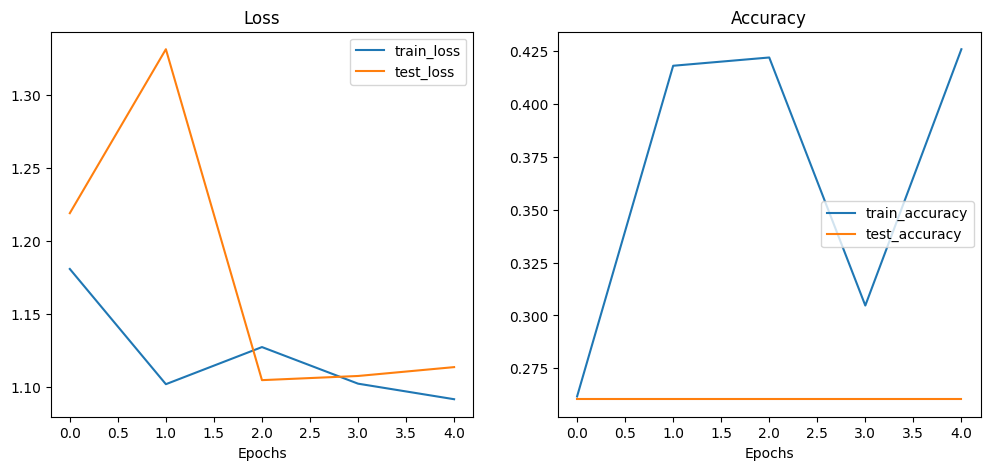

In [341]:
plot_loss_curves(model_1_results)

### 10. Compare Model Results


There are a few different ways to do this:
1. Hard codding
2. PyTorch + Tensorboard
3. weights & biases
4. MLFlow

In [342]:
import pandas as pd

model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [343]:
model_1_df

,train_loss,train_acc,test_loss,test_acc
0,1.180747,0.261719,1.219059,0.260417
1,1.101607,0.417969,1.331671,0.260417
2,1.127104,0.421875,1.104388,0.260417
3,1.101967,0.304688,1.107244,0.260417
4,1.091282,0.425781,1.113332,0.260417


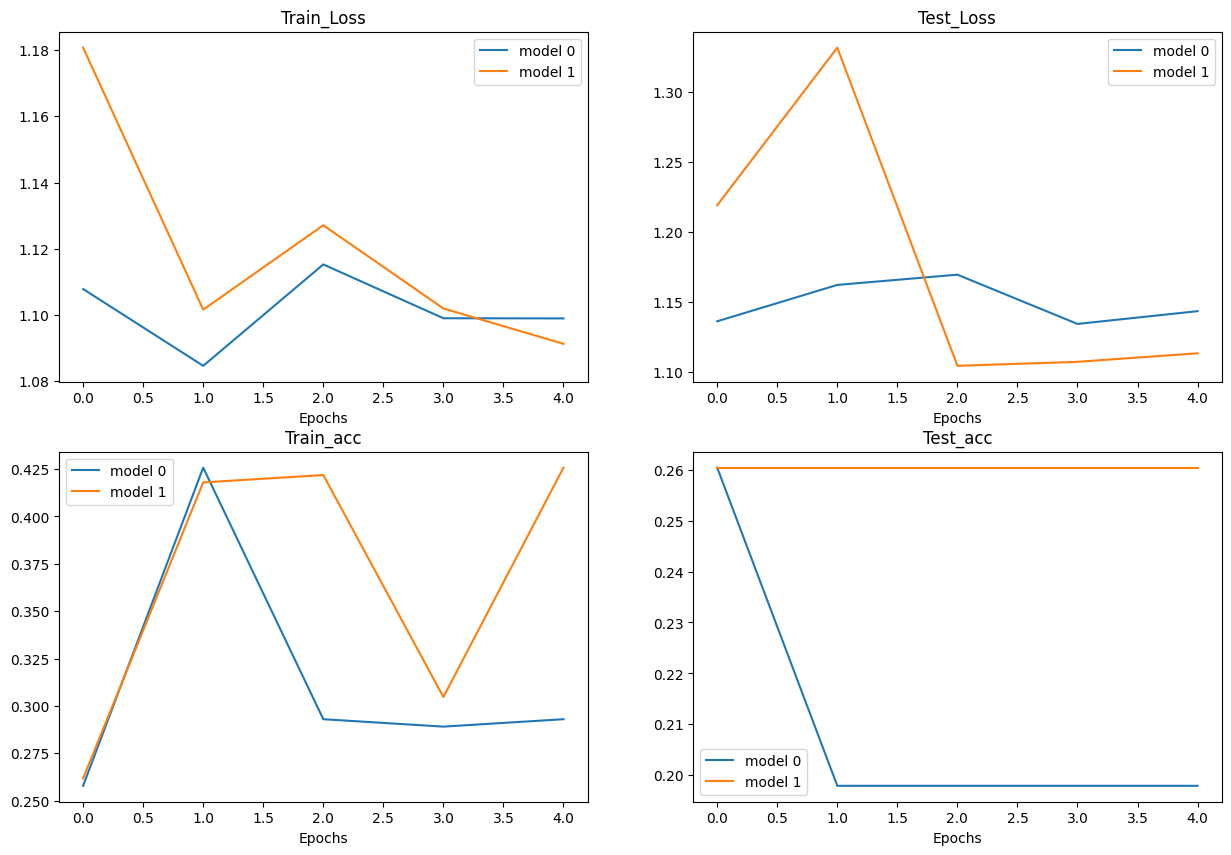

In [344]:
# setup a plot
plt.figure(figsize=(15, 10))

# get number of epochs
epochs = range(len(model_0_df))

# plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="model 0")
plt.plot(epochs, model_1_df["train_loss"], label="model 1")
plt.title("Train_Loss")
plt.xlabel("Epochs")
plt.legend()

# plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="model 0")
plt.plot(epochs, model_1_df["test_loss"], label="model 1")
plt.title("Test_Loss")
plt.xlabel("Epochs")
plt.legend()

# plot train loss
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="model 0")
plt.plot(epochs, model_1_df["train_acc"], label="model 1")
plt.title("Train_acc")
plt.xlabel("Epochs")
plt.legend()

# plot test Accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="model 0")
plt.plot(epochs, model_1_df["test_acc"], label="model 1")
plt.title("Test_acc")
plt.xlabel("Epochs")
plt.legend()


### 11. Making prediction on a custom image

In [345]:
# download custom image
import requests

# setup custom image path
custom_image_path = data_path / "/content/data/pizza_steak_sushi/train/pizza/1008844.jpg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
  with open(custom_image_path, "wb") as f:
    # when dowloading from github, need to use the "raw" file link
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
    print(f"Downloading {custom_image_path}...")

else:
  print(f"{custom_image_path} already exist, akipping download...")

/content/data/pizza_steak_sushi/train/pizza/1008844.jpg already exist, akipping download...


#### 11.1 Loading in a custom image with PyTorch

we have to make sure our custom image is in the same format as the data our model was trained on

* In tensor form with datatype(torch.float32)
* of shape 64x64x3
* on the right device

In [346]:
import torchvision

custom_image_path = "/content/data/pizza_steak_sushi/train/pizza/1008844.jpg"  # correct path
custom_image_uint8 = torchvision.io.read_image(custom_image_path)

print(custom_image_uint8.shape)

torch.Size([3, 512, 512])


In [347]:
import torchvision

# read in custom image
custom_image_unit8 = torchvision.io.read_image(str(custom_image_path))
print(f"ustom image tensor:\n {custom_image_unit8}")
print(f"ustom image tensor: {custom_image_unit8.shape}")
print(f"ustom image tensor: {custom_image_unit8.dtype}")

ustom image tensor:
 tensor([[[26, 27, 27,  ..., 29, 28, 28],
         [28, 28, 28,  ..., 28, 29, 30],
         [29, 29, 29,  ..., 28, 30, 31],
         ...,
         [40, 41, 42,  ..., 23, 22, 22],
         [39, 37, 38,  ..., 22, 22, 21],
         [42, 37, 36,  ..., 21, 21, 22]],

        [[12, 13, 13,  ..., 18, 17, 17],
         [14, 14, 14,  ..., 17, 18, 19],
         [15, 15, 15,  ..., 17, 19, 20],
         ...,
         [56, 57, 58,  ..., 27, 26, 26],
         [57, 55, 56,  ..., 26, 26, 25],
         [60, 55, 54,  ..., 25, 25, 26]],

        [[ 3,  4,  4,  ..., 24, 23, 23],
         [ 5,  5,  5,  ..., 23, 24, 25],
         [ 6,  6,  6,  ..., 23, 25, 26],
         ...,
         [43, 44, 45,  ..., 28, 27, 27],
         [43, 41, 42,  ..., 27, 27, 26],
         [46, 41, 40,  ..., 26, 26, 27]]], dtype=torch.uint8)
ustom image tensor: torch.Size([3, 512, 512])
ustom image tensor: torch.uint8


(<matplotlib.image.AxesImage at 0x7cd837c1e210>,)

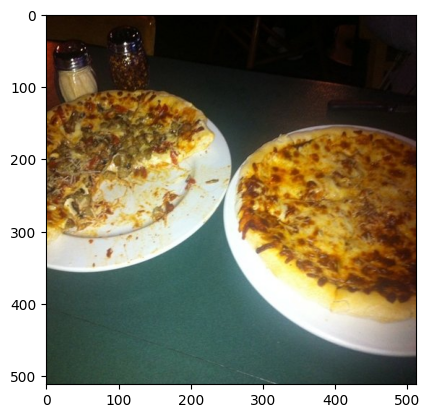

In [348]:
plt.imshow(custom_image_unit8.permute(1, 2, 0)),

#### 11.2 Making a prediction on a custom image with a traind PyTorch model

In [349]:
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float) / 255
custom_image

tensor([[[0.1020, 0.1059, 0.1059,  ..., 0.1137, 0.1098, 0.1098],
         [0.1098, 0.1098, 0.1098,  ..., 0.1098, 0.1137, 0.1176],
         [0.1137, 0.1137, 0.1137,  ..., 0.1098, 0.1176, 0.1216],
         ...,
         [0.1569, 0.1608, 0.1647,  ..., 0.0902, 0.0863, 0.0863],
         [0.1529, 0.1451, 0.1490,  ..., 0.0863, 0.0863, 0.0824],
         [0.1647, 0.1451, 0.1412,  ..., 0.0824, 0.0824, 0.0863]],

        [[0.0471, 0.0510, 0.0510,  ..., 0.0706, 0.0667, 0.0667],
         [0.0549, 0.0549, 0.0549,  ..., 0.0667, 0.0706, 0.0745],
         [0.0588, 0.0588, 0.0588,  ..., 0.0667, 0.0745, 0.0784],
         ...,
         [0.2196, 0.2235, 0.2275,  ..., 0.1059, 0.1020, 0.1020],
         [0.2235, 0.2157, 0.2196,  ..., 0.1020, 0.1020, 0.0980],
         [0.2353, 0.2157, 0.2118,  ..., 0.0980, 0.0980, 0.1020]],

        [[0.0118, 0.0157, 0.0157,  ..., 0.0941, 0.0902, 0.0902],
         [0.0196, 0.0196, 0.0196,  ..., 0.0902, 0.0941, 0.0980],
         [0.0235, 0.0235, 0.0235,  ..., 0.0902, 0.0980, 0.

In [350]:
# create transform pipline to resize image
from torchvision import transforms
custom_image_transform = transforms.Compose([
    transforms.Resize(size=(64, 64))
])

# transform target image
custom_image_transformed = custom_image_transform(custom_image)

# print out the shape
print(f"Original shape: {custom_image.shape}")
print(f"Transformed shape: {custom_image_transformed.shape}")

Original shape: torch.Size([3, 512, 512])
Transformed shape: torch.Size([3, 64, 64])


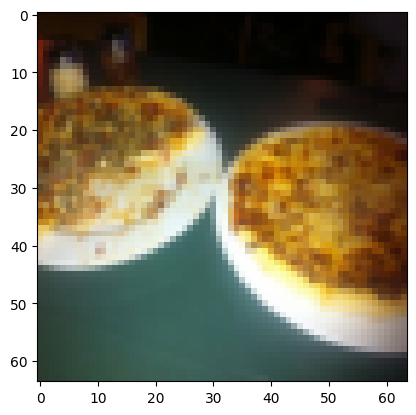

In [351]:
plt.imshow(custom_image_transformed.permute(1, 2, 0))

In [352]:
custom_image_transformed.shape, custom_image_transformed.unsqueeze(0).shape

(torch.Size([3, 64, 64]), torch.Size([1, 3, 64, 64]))

In [353]:
# try make a prediction on an image unit8 format
model_1.eval()
with torch.inference_mode():
  custom_image_pred = model_1(custom_image_transformed.unsqueeze(0).to(device))

custom_image_pred

torch.Size([1, 10, 32, 32])
torch.Size([1, 10, 16, 16])


tensor([[ 0.0675, -0.0068, -0.0461]])

Note, to make a prediction on a custom image we had to:

* Load the image and turn it into a tensor
* make sure the image was the same datatype as the model
* make sure the image was the same shape as the model was trained on(3, 64, 64) with a batch size
* make sure the image was on the same device as our model

In [354]:
# convert logits to prediction probability\
custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
custom_image_pred

tensor([[ 0.0675, -0.0068, -0.0461]])

In [355]:
# convert prediction probabilities to prediction labels
custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1).cpu()
custom_image_pred_label

tensor([0])

In [356]:
class_names[custom_image_pred_label]

'pizza'

#### 11. 2 Putting custom image prediction together: building a function

Ideal outcome:
A function where we pass an image path to and have our model predict on that image and plot the image + prediction.

In [357]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names=None,
                        transform=None,
                        device=device):
  """ Make a prediction on a target image with a trained model and plot the image"""
  # Load in the image
  target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

  # divide the image values by 255 to get them between [0, 1]
  target_image =  target_image / 255.

  # transform if necessary
  if transform:
    target_image = transform(target_image)

  # make sure the model is on the target device
  model.to(device)

  # Turn on eval/ inference mode and make a prediction
  model.eval()
  with torch.inference_mode():
    # add an extra dimension to the image (this is the batch dimension)
    target_image = target_image.unsqueeze(0)

    # make a prediction on the image with an extra dimension
    target_image_pred = model(target_image.to(device))# make sure the target image is

    # convert prediction logits into prediction probabilities
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # convert prediction probabilities into prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs,dim=1)

    # plot the image alongside the prediction and prediction probabilities
    plt.imshow(target_image.squeeze().permute(1, 2, 0 ))
    if class_names:
      title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"

    else:
      title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"

    plt.title(title)
    plt.axis(False)





torch.Size([1, 10, 32, 32])
torch.Size([1, 10, 16, 16])


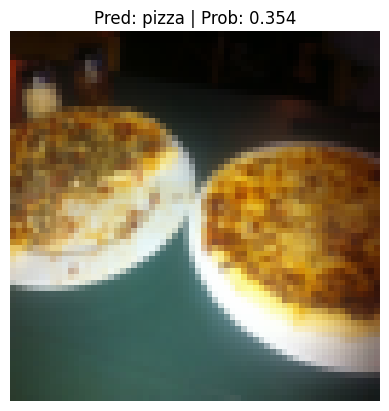

In [358]:
# pred on our custom image
pred_and_plot_image(model=model_1,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device
                    )